In [11]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv("ml_pipeline_v10.csv")

df.head()

,classifier,subject,session,fold,accuracy
0,optimized_ensemble,1,1,1,0.775
1,optimized_svm,1,1,1,0.775
2,optimized_ensemble,1,1,2,0.550
3,optimized_svm,1,1,2,0.475
4,optimized_ensemble,1,1,3,0.175


In [4]:
print("Shape:", df.shape)
print("\nClassifiers:", df['classifier'].unique())
print("\nSubjects:", df['subject'].unique())
print("\nSessions:", df['session'].unique())
print("\nFolds:", df['fold'].unique())

print("\nMissing values:\n", df.isnull().sum())

Shape: (110, 5)

Classifiers: ['optimized_ensemble' 'optimized_svm']

Subjects: [1 2 3 4]

Sessions: [1 2 3]

Folds: [1 2 3 4 5]

Missing values:
 classifier    0
subject       0
session       0
fold          0
accuracy      0
dtype: int64


In [8]:
# Overall Performance
overall = df.groupby("classifier")["accuracy"].agg(["mean", "std", "min", "max"])
print(overall)

                        mean       std  min    max
classifier                                        
optimized_ensemble  0.401364  0.198281  0.0  0.975
optimized_svm       0.389545  0.205181  0.0  0.950


In [7]:
# Performance per subject
subject_perf = df.groupby(["classifier", "subject"])["accuracy"].mean().unstack(0)
print(subject_perf)

classifier  optimized_ensemble  optimized_svm
subject                                      
1                     0.420000       0.378333
2                     0.355000       0.322500
3                     0.391667       0.401667
4                     0.423333       0.433333


In [9]:
# Fold Variance
fold_var = df.groupby(["classifier", "subject", "session"])["accuracy"].std()
print(fold_var.sort_values(ascending=False).head(10))

classifier          subject  session
optimized_svm       4        2          0.351603
optimized_ensemble  4        2          0.325288
optimized_svm       3        3          0.263984
                    4        3          0.248495
optimized_ensemble  3        3          0.246475
                    1        1          0.236247
optimized_svm       1        1          0.234521
                    2        1          0.225416
optimized_ensemble  4        3          0.221783
                    2        1          0.205396
Name: accuracy, dtype: float64


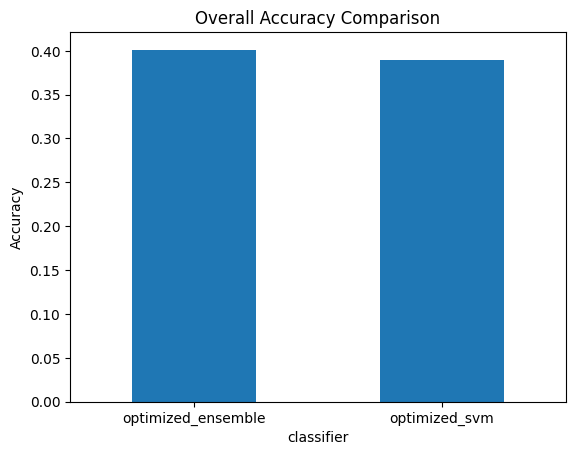

In [13]:
# Plot: SVM vs Ensemble
means = df.groupby("classifier")["accuracy"].mean()

plt.figure()
means.plot(kind="bar")
plt.title("Overall Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()

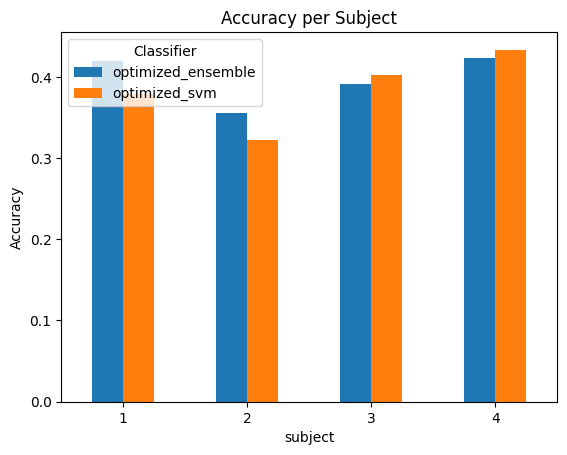

In [14]:
# Plot: Subject-wise Comparison
subject_perf.plot(kind="bar")
plt.title("Accuracy per Subject")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.legend(title="Classifier")
plt.show()

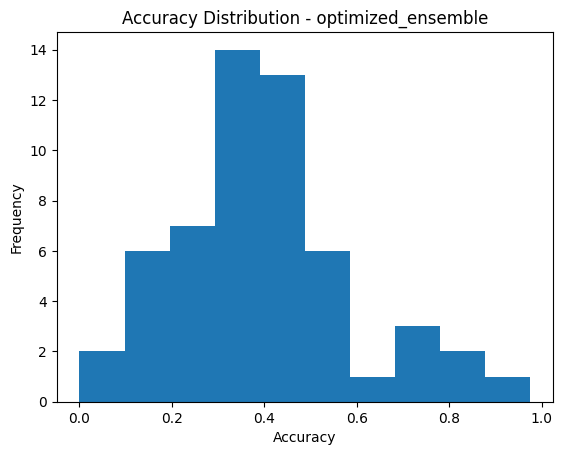

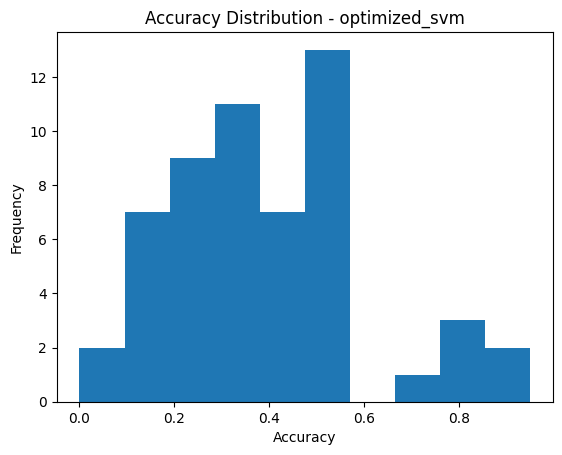

In [15]:
# Plot: Fold Distribution
for clf in df["classifier"].unique():
    subset = df[df["classifier"] == clf]
    
    plt.figure()
    plt.hist(subset["accuracy"], bins=10)
    plt.title(f"Accuracy Distribution - {clf}")
    plt.xlabel("Accuracy")
    plt.ylabel("Frequency")
    plt.show()

In [16]:
bad_folds = df[df["accuracy"] < 0.2]
print("Very low accuracy folds:\n")
print(bad_folds)

Very low accuracy folds:

             classifier  subject  session  fold  accuracy
4    optimized_ensemble        1        1     3     0.175
5         optimized_svm        1        1     3     0.125
27        optimized_svm        1        3     4     0.150
35        optimized_svm        2        1     3     0.150
36   optimized_ensemble        2        1     4     0.000
37        optimized_svm        2        1     4     0.000
54   optimized_ensemble        3        1     3     0.175
65        optimized_svm        3        2     3     0.150
76   optimized_ensemble        3        3     4     0.175
82   optimized_ensemble        4        1     2     0.075
83        optimized_svm        4        1     2     0.100
88   optimized_ensemble        4        1     5     0.125
89        optimized_svm        4        1     5     0.150
96   optimized_ensemble        4        2     4     0.150
97        optimized_svm        4        2     4     0.075
106  optimized_ensemble        4        3     

In [17]:
print("Top 10 runs:")
print(df.sort_values("accuracy", ascending=False).head(10))

print("\nWorst 10 runs:")
print(df.sort_values("accuracy", ascending=True).head(10))

Top 10 runs:
             classifier  subject  session  fold  accuracy
90   optimized_ensemble        4        2     1     0.975
91        optimized_svm        4        2     1     0.950
73        optimized_svm        3        3     2     0.875
72   optimized_ensemble        3        3     2     0.825
101       optimized_svm        4        3     1     0.825
92   optimized_ensemble        4        2     2     0.800
100  optimized_ensemble        4        3     1     0.775
93        optimized_svm        4        2     2     0.775
0    optimized_ensemble        1        1     1     0.775
1         optimized_svm        1        1     1     0.775

Worst 10 runs:
             classifier  subject  session  fold  accuracy
36   optimized_ensemble        2        1     4     0.000
37        optimized_svm        2        1     4     0.000
97        optimized_svm        4        2     4     0.075
82   optimized_ensemble        4        1     2     0.075
83        optimized_svm        4        1  

In [18]:
# Stability score
stability = df.groupby("classifier")["accuracy"].std()
print("Lower is better (more stable):\n", stability)

Lower is better (more stable):
 classifier
optimized_ensemble    0.198281
optimized_svm         0.205181
Name: accuracy, dtype: float64


In [19]:
print("Summary Insights:\n")

for clf in df["classifier"].unique():
    subset = df[df["classifier"] == clf]
    
    print(f"--- {clf} ---")
    print("Mean:", subset["accuracy"].mean())
    print("Std :", subset["accuracy"].std())
    print("Min :", subset["accuracy"].min())
    print("Max :", subset["accuracy"].max())
    print()

Summary Insights:

--- optimized_ensemble ---
Mean: 0.4013636363636363
Std : 0.1982806992378121
Min : 0.0
Max : 0.975

--- optimized_svm ---
Mean: 0.3895454545454545
Std : 0.20518120430323677
Min : 0.0
Max : 0.95

